## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

C:\Users\rasto\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Dataset

In [2]:
data=pd.read_csv("train_1.csv")

In [3]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Understand the dataset

In [4]:
data.shape

(1460, 81)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## Select features and target

In [8]:
X=data[["GrLivArea","BedroomAbvGr","FullBath"]]

In [9]:
y=data["SalePrice"]

## Split data into training and testing

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train.shape

(1168, 3)

In [12]:
X_test.shape

(292, 3)

## Create Linear Regression model

In [14]:
model =LinearRegression()

## Train the model

In [15]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
model.coef_

array([   104.02630701, -26655.16535734,  30014.32410896])

In [17]:
model.intercept_

np.float64(52261.748626944594)

In [19]:
print("Coefficients :",model.coef_)
print("Intercept:", model.intercept_)

Coefficients : [   104.02630701 -26655.16535734  30014.32410896]
Intercept: 52261.748626944594


## Make predictions

In [21]:
y_pred=model.predict(X_test)
print(y_pred)

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196 185971.75622995  93229.5689926
 121965.26049018 192005.28203666 208129.35962356 133824.25948958
 211250.14883393 146931.57417313 134240.36471763 186179.80884397
 219884.33231595 197726.72892233 185867.72992294 126334.3653847
 181186.54610738 183707.60823788 171720.15216927 118844.47127982
 199183.09722051 199623.63321076 132551.51304323 245162.72491993
 383364.40832164 127998.78629689 202511.9390449  120484.46142981
 200376.66521523 206232.45533514 241160.86372906 120716.94480604
 124645.5137103  251820.40856871 101135.56832553 244746.61969188
 105088.56799199 208912.70855526 123837.7340164  101655.69986059
 271169.30167299 160846.66855057 105088.56799199 221989.28921839
 137960.88100787 360448.30385172 143835.21572496 212706.5171321
 216971.5957196  149458.52246864 118507.96159658 114995.49792036
 109714.58702494 131927.3552

In [22]:
comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison.head(10)

,Actual,Predicted
892,154500,113410.672553
1105,325000,305081.877759
413,115000,135904.785630
522,159000,205424.675641
1036,315500,227502.683490
614,75500,121157.480796
218,311500,205577.980566
1160,146000,183787.203783
649,84500,121157.480796
887,135500,147219.222332


## Calculate MAE

In [23]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE :",mae)

MAE : 35788.061292436294


## Calculate MSE

In [24]:
mse = mean_squared_error(y_test, y_pred)
print("MSE :",mse)

MSE : 2806426667.247853


## Calculate RMSE

In [25]:
rmse=mse**0.5
print("RMSE :",rmse)

RMSE : 52975.71771338122


## Calculate R² score

In [26]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6341189942328371


## Print all evaluation metrics together

In [27]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 35788.061292436294
Mean Squared Error: 2806426667.247853
Root Mean Squared Error: 52975.71771338122
R2 Score: 0.6341189942328371


## Plot Actual vs Predicted

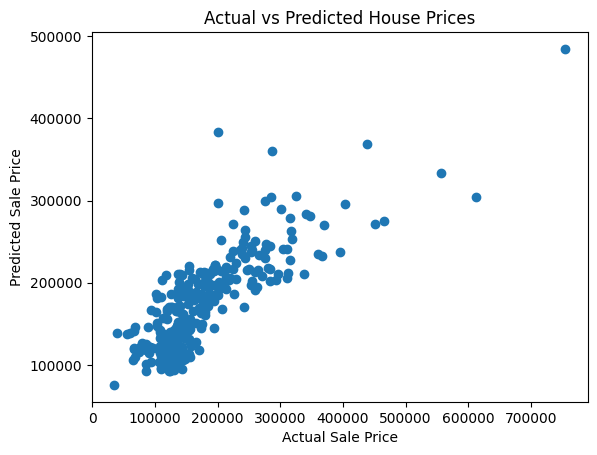

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Plot regression relationship

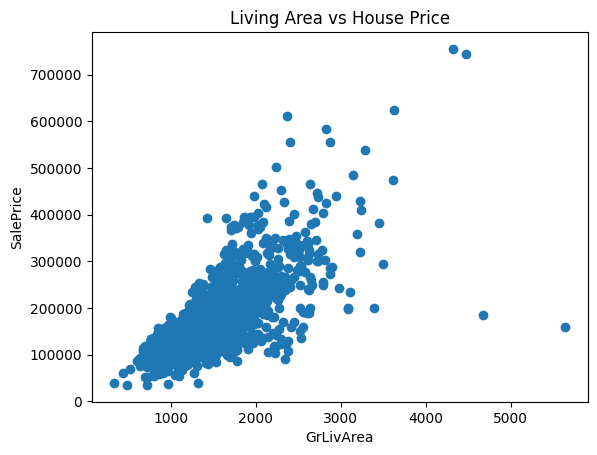

In [30]:
plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Living Area vs House Price")
plt.show()